In [9]:
# Read matlab data from simualtion
import scipy.io
import numpy as np

data = scipy.io.loadmat('./Data/SimData.mat')


Mean Squared Error: 0.002703331345903321
R2 Score: 0.8644565516963789


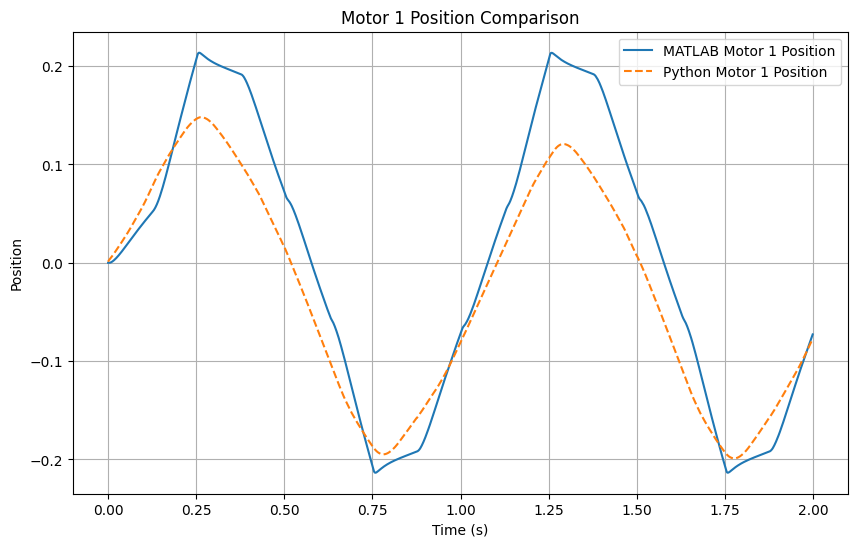

In [10]:
#Load Motor1 data
# time vector for 2s and dt 0.001s
t = np.arange(0, 2, 0.001)
motor_p_m = data['motor_pout1']
#load csv from implementation
motor_p_s= np.loadtxt('./OutputData/motor_states_history_motor_1.csv', delimiter=',')
# Print mse and r2 score
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(motor_p_m[:len(t), 4], motor_p_s[:len(t), 1])
r2 = r2_score(motor_p_m[:len(t), 4], motor_p_s[:len(t), 1])
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")
# Plot comparison
import matplotlib.pyplot as plt     
plt.figure(figsize=(10, 6))
plt.plot(t, motor_p_m[:len(t), 4], label='MATLAB Motor 1 Position')
plt.plot(t, motor_p_s[:len(t), 1], label='Python Motor 1 Position', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Position')
plt.title('Motor 1 Position Comparison')
plt.legend()
plt.grid(True)
plt.show()

Mean Squared Error (u signal): 34.884249129112334
R2 Score (u signal): -1.486518969798881


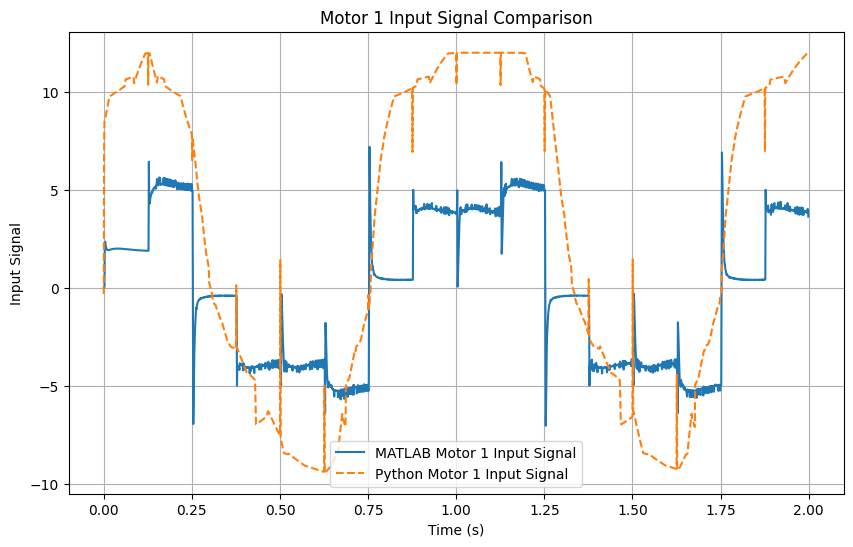

In [11]:
# Compate u signal
u_signal_m = motor_p_m[:, 0]
u_signal_s = np.loadtxt('./OutputData/motor_u_signals_history_motor_1.csv', delimiter=',')
#print mse and r2 score
mse_u = mean_squared_error(u_signal_m[:len(t)], u_signal_s[:len(t)])
r2_u = r2_score(u_signal_m[:len(t)], u_signal_s[:len(t)])
print(f"Mean Squared Error (u signal): {mse_u}")
print(f"R2 Score (u signal): {r2_u}")
# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(t, u_signal_m[:len(t)], label='MATLAB Motor 1 Input Signal')
plt.plot(t, u_signal_s[:len(t)], label='Python Motor 1 Input Signal', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Input Signal')
plt.title('Motor 1 Input Signal Comparison')
plt.legend()
plt.grid(True)
plt.show()

Mean Squared Error (Kt): 0.021089552352075408
R2 Score (Kt): -0.5429255700592253
Mean Squared Error (Caudal Amplitude): 0.007051933069062189
R2 Score (Caudal Amplitude): -4.726921918759836
Mean Squared Error (Caudal Angle): 0.06040077202517773
R2 Score (Caudal Angle): -1.5201204126731387


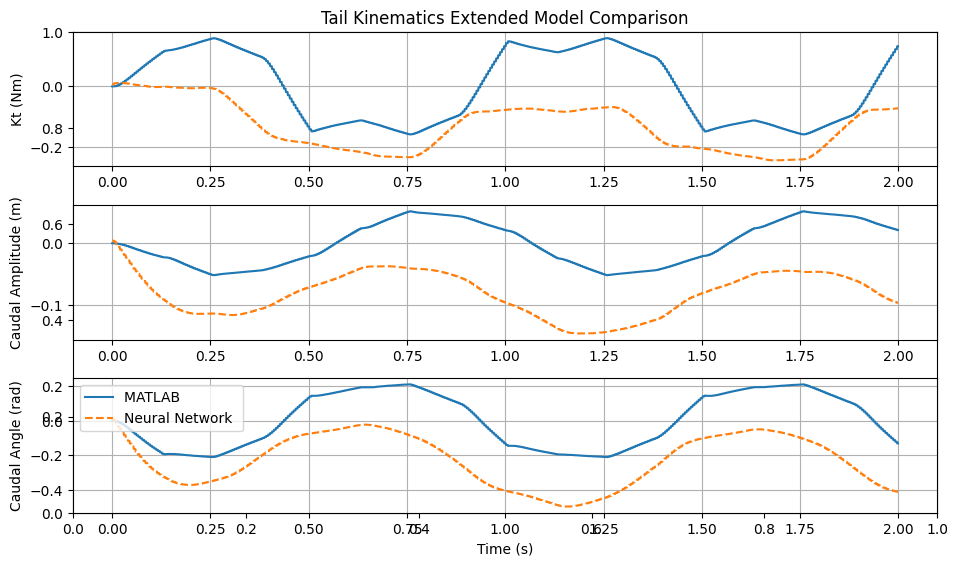

In [12]:
#plot tail forces from tail kinematics
import math
kt = data['Moments_Add_out']
caudal = data['cout']
tail_forces_s = np.loadtxt('./OutputData/tail_kinematics_history.csv', delimiter=',')
#print mse and r2 score
mse_kt = mean_squared_error(kt[:len(t), 0], tail_forces_s[:len(t), 0])
r2_kt = r2_score(kt[:len(t), 0], tail_forces_s[:len(t), 0])
mse_caudal_amp = mean_squared_error(caudal[:len(t), 0], tail_forces_s[:len(t), 1])
r2_caudal_amp = r2_score(caudal[:len(t), 0], tail_forces_s[:len(t), 1])
mse_caudal_angle = mean_squared_error(caudal[:len(t), 1]*math.pi/180, tail_forces_s[:len(t), 2])
r2_caudal_angle = r2_score(caudal[:len(t), 1]*math.pi/180, tail_forces_s[:len(t), 2])
print(f"Mean Squared Error (Kt): {mse_kt}")
print(f"R2 Score (Kt): {r2_kt}")
print(f"Mean Squared Error (Caudal Amplitude): {mse_caudal_amp}")
print(f"R2 Score (Caudal Amplitude): {r2_caudal_amp}")
print(f"Mean Squared Error (Caudal Angle): {mse_caudal_angle}")
print(f"R2 Score (Caudal Angle): {r2_caudal_angle}")
# Plot comparison
plt.figure(figsize=(10, 6))
plt.title('Tail Kinematics Extended Model Comparison')
plt.subplot(3, 1, 1)
plt.plot(t, kt[:len(t), 0], label='MATLAB Tail Moment Kt')
plt.plot(t, tail_forces_s[:len(t), 0], label='Python Tail Moment Kt', linestyle='--')
plt.ylabel('Kt (Nm)')
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t, caudal[:len(t), 0], label='MATLAB Caudal Fin Amplitude')
plt.plot(t, tail_forces_s[:len(t), 1], label='Python Caudal Fin Amplitude', linestyle='--')
plt.ylabel('Caudal Amplitude (m)')
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t, caudal[:len(t), 1]*math.pi/180, label='MATLAB ')
plt.plot(t, tail_forces_s[:len(t), 2], label='Neural Network ', linestyle='--')
plt.ylabel('Caudal Angle (rad)')
plt.grid()
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()


(2000, 7)
Mean Squared Error (Thrust): [2.81372745 0.10993432 1.62286504 0.33623785 0.02334476 0.50893053
 0.38288034]
R2 Score (Thrust): [-6.17099551e+01 -6.13345411e+01  0.00000000e+00 -3.41973188e+01
 -7.83908970e-01  0.00000000e+00 -7.27533971e+10]
(2000, 7)


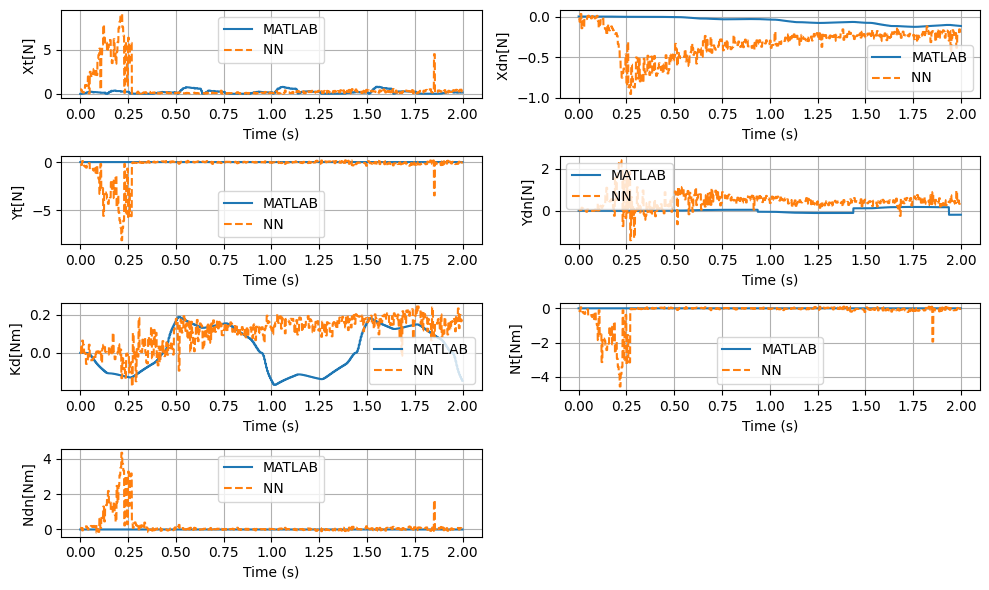

In [15]:
# Thrust comparison
thrust_m = data['Tail_Forces_out'][:, [0, 1, 2, 3, 7, 10, 11]]
print(thrust_m.shape)
thrust_s = np.loadtxt('./OutputData/thrust_history.csv', delimiter=',')
#print mse and r2 score
mse_thrust = mean_squared_error(thrust_m[:len(t), :], thrust_s[:len(t), :], multioutput='raw_values')
r2_thrust = r2_score(thrust_m[:len(t), :], thrust_s[:len(t), :], multioutput='raw_values')
print(f"Mean Squared Error (Thrust): {mse_thrust}")
print(f"R2 Score (Thrust): {r2_thrust}")
print(thrust_s.shape)
force_labels = ['Xt[N]', 'Xdn[N]', 'Yt[N]', 'Ydn[N]', 'Kd[Nm]', 'Nt[Nm]', 'Ndn[Nm]']
plt.figure(figsize=(10, 6))
for i in range(thrust_m.shape[1]):
    plt.subplot(4, 2, i+1)
    plt.plot(t, thrust_m[:len(t), i], label='MATLAB')
    plt.plot(t, thrust_s[:len(t), i], label='NN ', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel(f'{force_labels[i]} ')
    plt.legend()
    plt.grid()
plt.tight_layout()

State: u - Mean Squared Error: 0.010751109354025467, R2 Score: -17.868911250607667
State: v - Mean Squared Error: 0.0008583992887605212, R2 Score: -206.87680558952465
State: w - Mean Squared Error: 8.5683738099933e-06, R2 Score: -6484.785630402405
State: p - Mean Squared Error: 0.04943676502934808, R2 Score: -0.5520504942481863
State: q - Mean Squared Error: 6.148902765289817e-06, R2 Score: -419013.9536859829
State: r - Mean Squared Error: 0.011797643021452598, R2 Score: -306543.7656994222
State: xe - Mean Squared Error: 0.011441364893783142, R2 Score: -17.475745652411472
State: ye - Mean Squared Error: 0.0008389251212728684, R2 Score: -10864.332455007461
State: ze - Mean Squared Error: 1.3094513064970669e-08, R2 Score: 0.0
State: roll - Mean Squared Error: 0.03220923544883618, R2 Score: -36.53177132241896
State: pitch - Mean Squared Error: 1.1186417836979544e-05, R2 Score: -9257441.000635335
State: yaw - Mean Squared Error: 0.002641231421806701, R2 Score: -1876420.8230346167


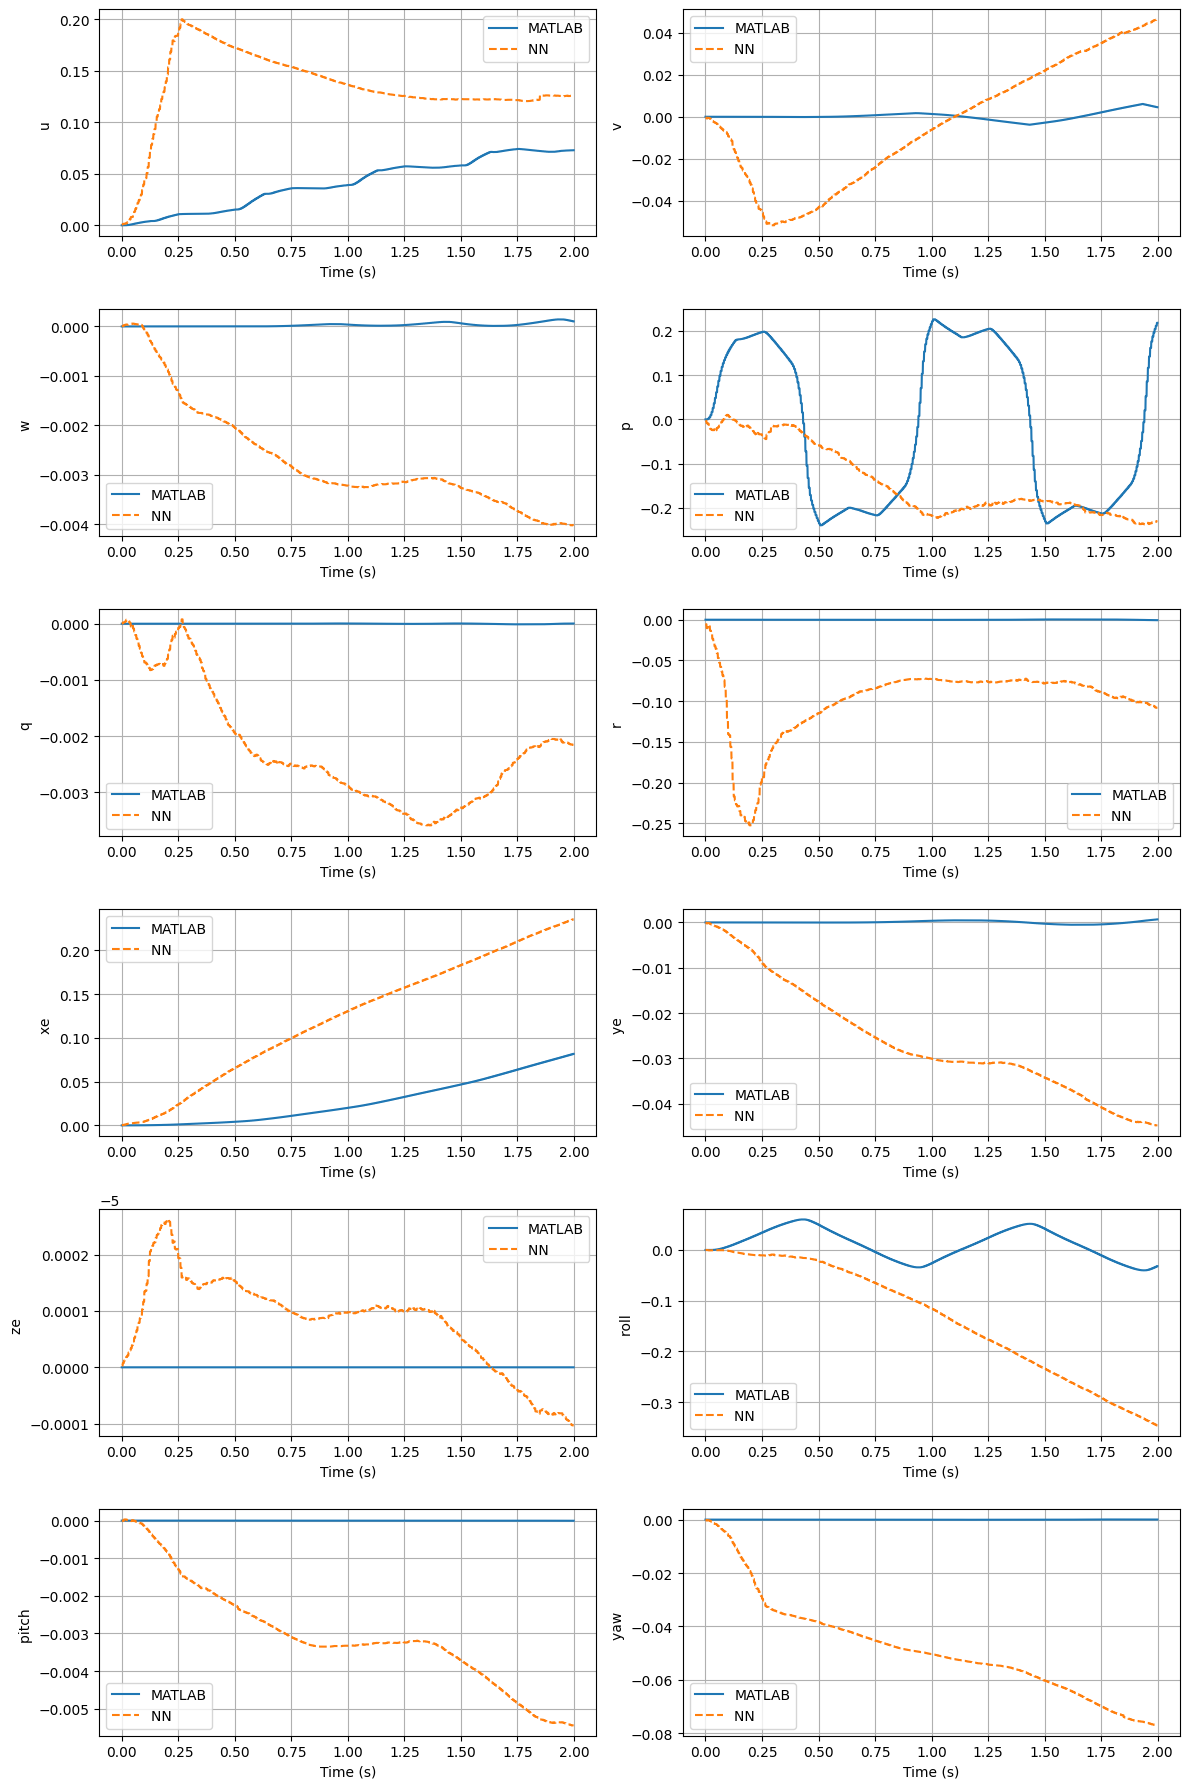

In [16]:
# Evaluate each Rigid Body model
x_rigid_body_m = data['xout']
x_rigid_body_s = np.loadtxt('./OutputData/rigid_body_states_history.csv', delimiter=',')
x_labels = ['u', 'v', 'w', 'p', 'q', 'r', 'xe', 'ye', 'ze', 'roll', 'pitch', 'yaw']
# get mse and r2 score for each state
for i in range(x_rigid_body_m.shape[1]):
    mse_rb = mean_squared_error(x_rigid_body_m[:len(t), i], x_rigid_body_s[:len(t), i])
    r2_rb = r2_score(x_rigid_body_m[:len(t), i], x_rigid_body_s[:len(t), i])
    print(f"State: {x_labels[i]} - Mean Squared Error: {mse_rb}, R2 Score: {r2_rb}")
plt.figure(figsize=(12, 18))
for i in range(x_rigid_body_m.shape[1]):
    plt.subplot(6, 2, i+1)
    plt.plot(t, x_rigid_body_m[:len(t), i], label='MATLAB')
    plt.plot(t, x_rigid_body_s[:len(t), i], label='NN ', linestyle='--')
    plt.xlabel('Time (s)')
    plt.ylabel(f'{x_labels[i]} ')
    plt.legend()
    plt.grid()
plt.tight_layout()

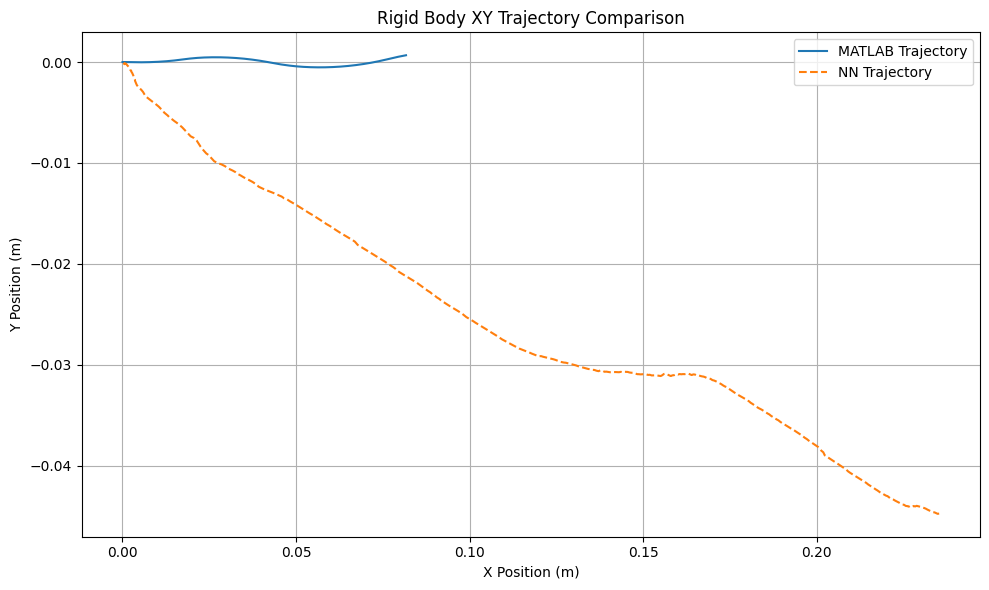

In [29]:
#plot x,y position comparison
plt.figure(figsize=(10, 6))
plt.plot(x_rigid_body_m[:len(t), 6], x_rigid_body_m[:len(t), 7], label='MATLAB Trajectory')
plt.plot(x_rigid_body_s[:len(t), 6], x_rigid_body_s[:len(t), 7], label='NN Trajectory', linestyle='--')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.title('Rigid Body XY Trajectory Comparison')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()